In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from scipy.stats.mstats import winsorize
from scipy import stats

In [9]:
DATA_PATH = "../data/processed/all_merged.parquet"
df = pd.read_parquet(DATA_PATH)

print("Loaded dataframe shape:", df.shape)
df.head()


Loaded dataframe shape: (8914963, 40)


,transaction_id,timestamp,user_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,total_debt,credit_score,num_credit_cards,mcc_description,transaction_hour,transaction_dayofweek,amount_non_positive_flag,age_out_of_range_flag,computed_age,age_mismatch_flag
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,swipe transaction,59935,Beulah,ND,58523,...,110153.0,740,4,Miscellaneous Food Stores,0,4,1,0,21,1
1,7475328,2010-01-01 00:02:00,561,4575,14.57,swipe transaction,67570,Bettendorf,IA,52722,...,112139.0,834,5,Department Stores,0,4,0,0,39,1
2,7475329,2010-01-01 00:02:00,1129,102,80.00,swipe transaction,27092,Vista,CA,92084,...,36540.0,686,3,Money Transfer,0,4,0,0,40,1
3,7475332,2010-01-01 00:06:00,848,3915,46.41,swipe transaction,13051,Harwood,MD,20776,...,96182.0,711,2,Drinking Places (Alcoholic Beverages),0,4,0,0,42,1
4,7475333,2010-01-01 00:07:00,1807,165,4.81,swipe transaction,20519,Bronx,NY,10464,...,98613.0,828,5,Book Stores,0,4,0,0,38,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 40 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   transaction_id            int64         
 1   timestamp                 datetime64[ns]
 2   user_id                   int64         
 3   card_id                   int64         
 4   amount                    float64       
 5   use_chip                  object        
 6   merchant_id               int64         
 7   merchant_city             object        
 8   merchant_state            object        
 9   zip                       int32         
 10  merchant_category_code    object        
 11  target                    int8          
 12  card_brand                object        
 13  card_type                 object        
 14  expires                   object        
 15  has_chip                  object        
 16  num_cards_issued          int64         
 17  credit_l

## Exploratory Data Analysis

### Univariate Analysis

Numerical Features

In [6]:
# Output folder for saving the plots
output_dir = r"..\reports\figures"

In [7]:

# Selecting numerical features
numerical_features = [
    'amount', 'current_age', 'credit_score', 'total_debt',
    'yearly_income', 'per_capita_income', 'num_credit_cards',
    'transaction_hour', 'transaction_dayofweek'
]

# Plot and save each histogram
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[feature], kde=True, bins=50)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()

    # Save plot
    save_path = os.path.join(output_dir, f"{feature}_histogram.png")
    plt.savefig(save_path, dpi=300)
    plt.close()

print("Plots saved to:", output_dir)

Plots saved to: ..\reports\figures


The transaction amount distribution is highly right-skewed, with most values clustered near zero and a long tail extending up to ~6,700. The strong skew and extreme high amounts indicate presence of outliers
Action:
Log-transform or quantile binning may help stabilize this feature.
Large amounts are rare and should be treated as high-risk during modeling.

In [13]:
!pip install -q kaleido


In [14]:
# Create and save boxplots
for feature in numerical_features:

    fig = px.box(
        df,
        y=feature,
        points="suspectedoutliers",     # highlights extreme values
        title=f"Boxplot of {feature}"
    )

    save_path = os.path.join(output_dir, f"{feature}_boxplot.png")
    fig.write_image(save_path)

print("Boxplots saved to:", output_dir)

Boxplots saved to: ..\reports\figures


In [22]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features


['use_chip',
 'merchant_city',
 'merchant_state',
 'merchant_category_code',
 'card_brand',
 'card_type',
 'expires',
 'has_chip',
 'acct_open_date',
 'card_on_dark_web',
 'gender',
 'mcc_description']

In [16]:
def eda_categorical(df, column, top_n=10):
    print(f"\n===== CATEGORICAL FEATURE: {column} =====")

    # Unique count
    print("Unique categories:", df[column].nunique(dropna=False))

    # Missing values
    print("Missing values:", df[column].isna().sum())

    # Top categories
    print("\nTop categories:")
    print(df[column].value_counts(dropna=False).head(top_n))
    
    # Rare categories (frequency < 100 for example)
    rare_count = (df[column].value_counts() < 100).sum()
    print("\nRare categories (<100 records):", rare_count)


In [17]:
for col in categorical_features:
    eda_categorical(df, col)



===== CATEGORICAL FEATURE: use_chip =====
Unique categories: 3
Missing values: 0

Top categories:
use_chip
swipe transaction     4668212
chip transaction      3202776
online transaction    1043975
Name: count, dtype: int64

Rare categories (<100 records): 0

===== CATEGORICAL FEATURE: merchant_city =====
Unique categories: 12173
Missing values: 0

Top categories:
merchant_city
ONLINE          1047865
Houston           98502
Miami             58680
Brooklyn          56173
Los Angeles       54969
Chicago           48652
Dallas            48136
Louisville        44160
Philadelphia      41126
San Antonio       39544
Name: count, dtype: int64

Rare categories (<100 records): 8654

===== CATEGORICAL FEATURE: merchant_state =====
Unique categories: 200
Missing values: 0

Top categories:
merchant_state
ONLINE    1047865
CA         956356
TX         677139
NY         574521
FL         469600
OH         324098
IL         313592
NC         286937
PA         280037
MI         266745
Name: count, 

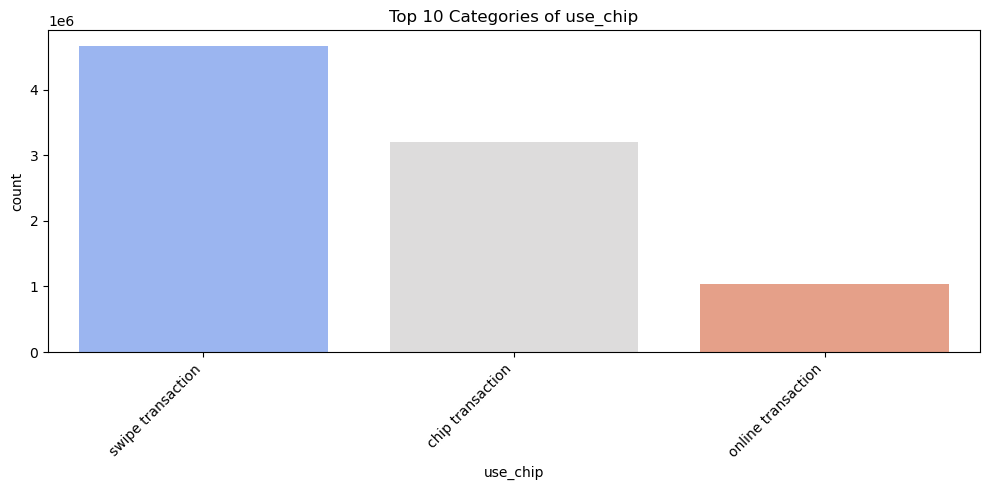

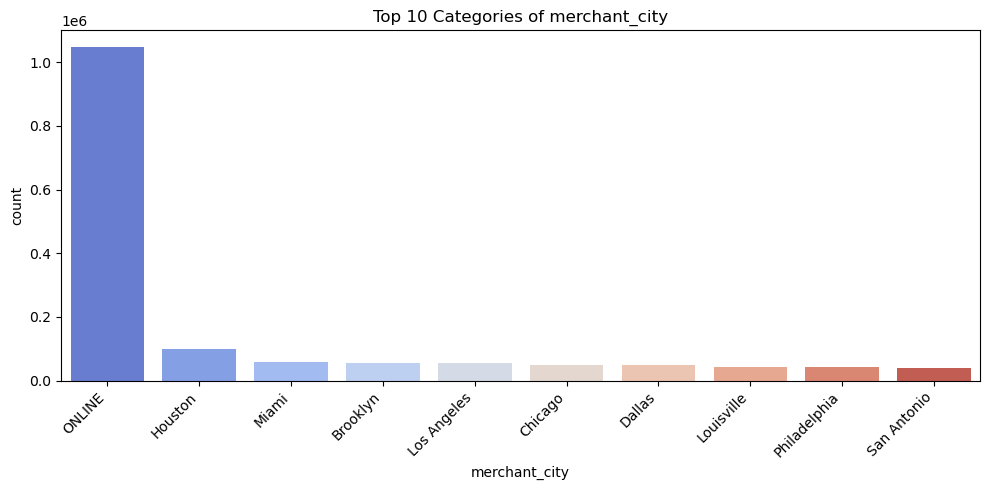

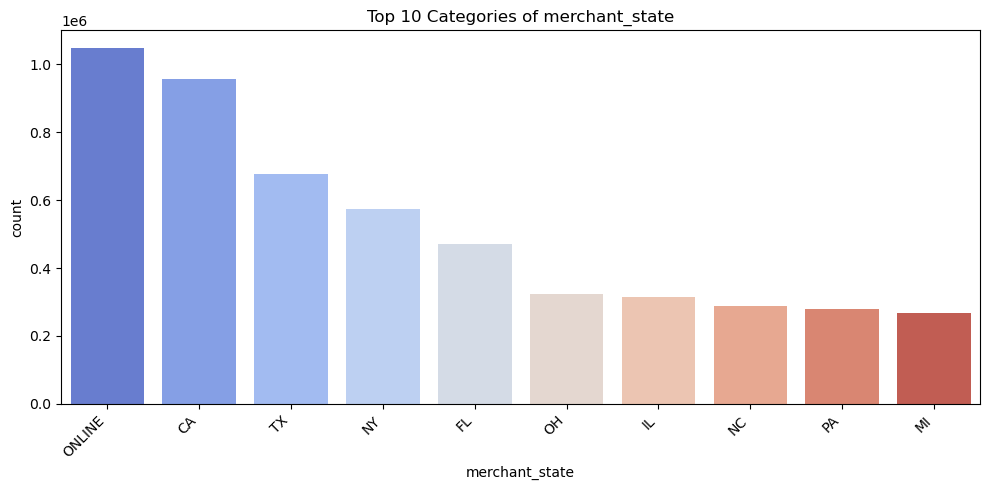

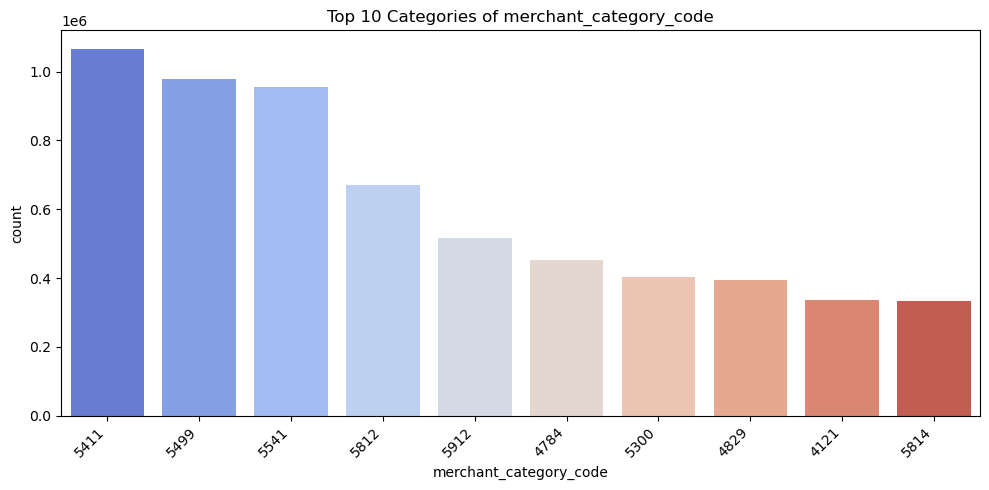

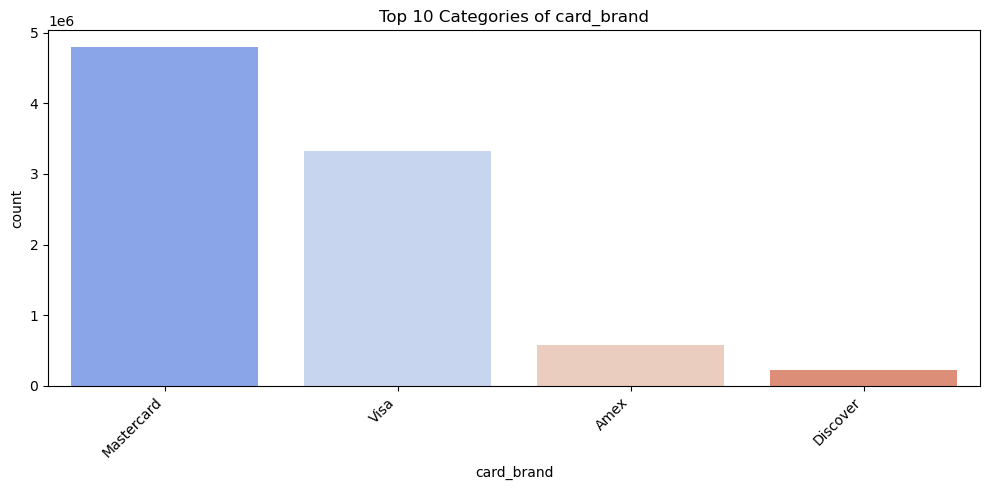

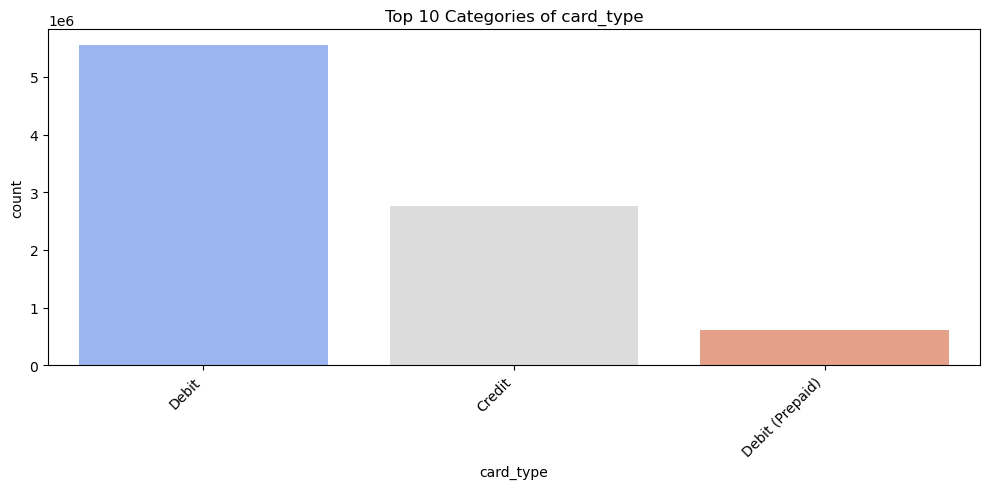

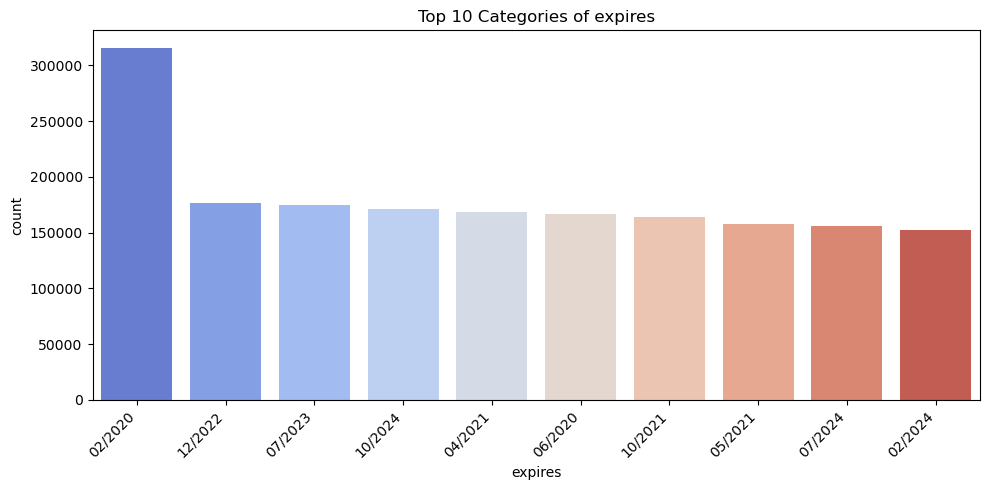

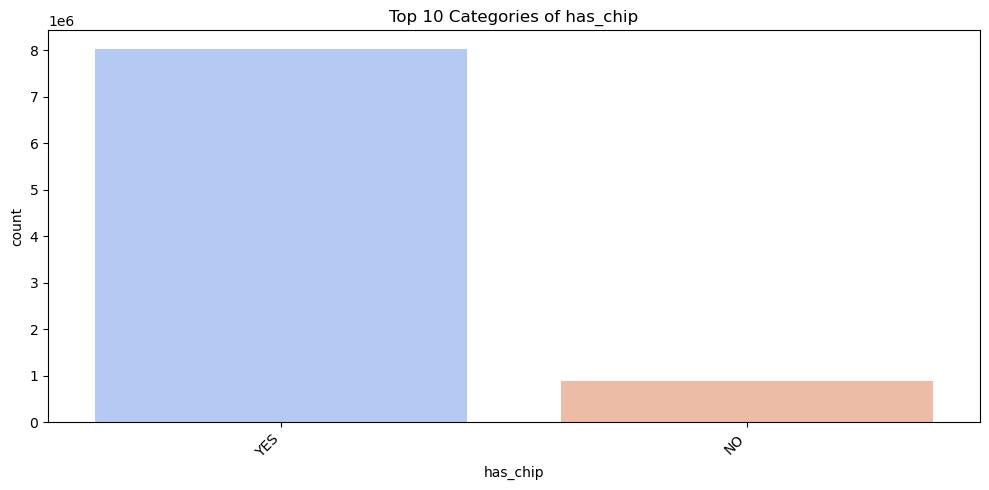

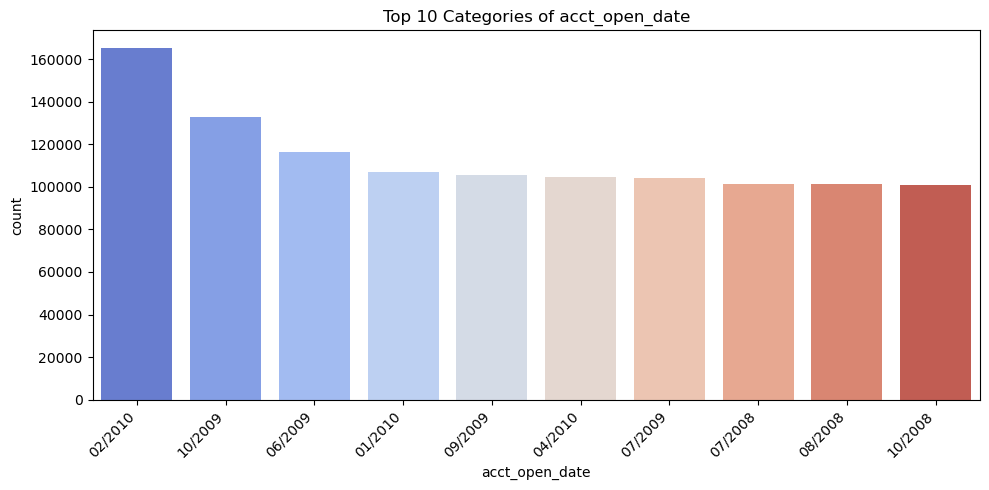

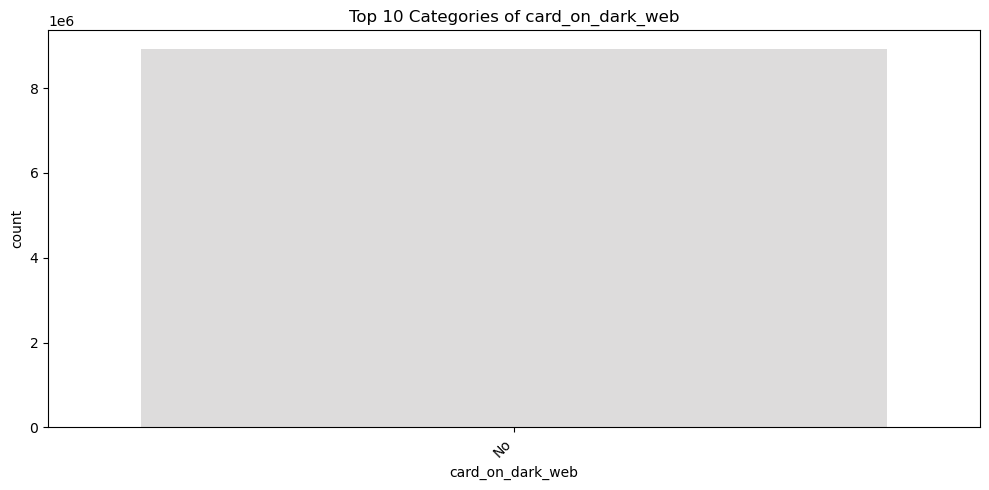

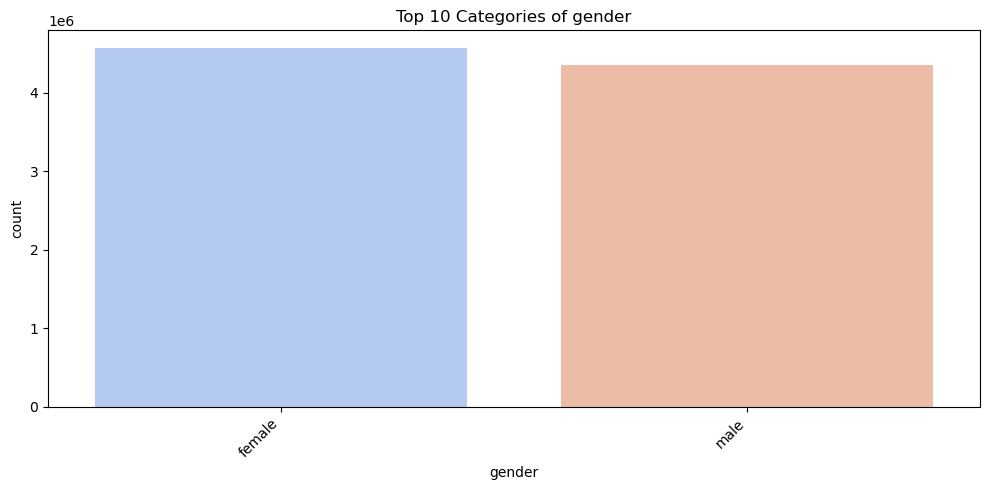

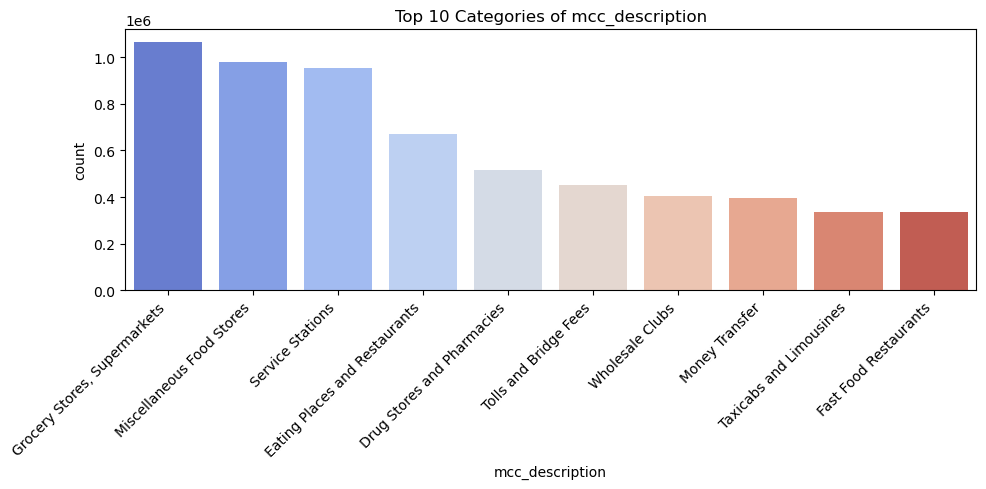

Categorical plots saved to: ..\reports\figures\categorical_plots


In [20]:
# Folder to save plots
output_dir = r"..\reports\figures\categorical_plots"
os.makedirs(output_dir, exist_ok=True)

TOP_N = 10  # number of categories to plot

for feature in categorical_features:

    plt.figure(figsize=(10, 5))

    # Plot only top N categories
    top_values = df[feature].value_counts().head(TOP_N).index

    sns.countplot(
        data=df[df[feature].isin(top_values)],
        x=feature,
        palette="coolwarm",
        order=top_values
    )

    plt.xticks(rotation=45, ha='right')
    plt.title(f"Top {TOP_N} Categories of {feature}")
    plt.tight_layout()
    plt.show()
    
    # Save plot
    save_path = os.path.join(output_dir, f"{feature}_top{TOP_N}_countplot.png")
    plt.savefig(save_path, dpi=300)

    plt.close()

print("Categorical plots saved to:", output_dir)

In [21]:
TOP_N = 10  # number of categories to plot

for feature in categorical_features:
    plt.figure(figsize=(10, 5))

    # Plot only top N categories
    top_values = df[feature].value_counts().head(TOP_N).index

    sns.countplot(
        data=df[df[feature].isin(top_values)],
        x=feature,
        palette="coolwarm",
        order=top_values
    )

    plt.xticks(rotation=45, ha='right')
    plt.title(f"Top {TOP_N} Categories of {feature}")
    plt.tight_layout()

    # Save BEFORE showing
    save_path = os.path.join(output_dir, f"{feature}_top{TOP_N}_countplot.png")
    plt.savefig(save_path, dpi=300)

    # Optional: show in notebook
    # plt.show()

    plt.close()

print("Categorical plots saved to:", output_dir)

Categorical plots saved to: ..\reports\figures\categorical_plots


### Fraud Rate tables

In [23]:
def fraud_rate_by_bin(df, feature, bins, labels=None):
    """
    Compute fraud rate and counts for a binned numerical feature.
    """
    tmp = df[[feature, 'target']].copy()
    tmp['bin'] = pd.cut(tmp[feature], bins=bins, labels=labels, include_lowest=True)

    agg = (
        tmp.groupby('bin')['target']
        .agg(['count', 'sum', 'mean'])
        .rename(columns={'count': 'n_txn', 'sum': 'n_fraud', 'mean': 'fraud_rate'})
        .reset_index()
    )
    return agg

In [41]:
amount_bins = [-np.inf, 0, 10, 50, 100, 200, 500, 1000, np.inf]
amount_labels = [
    "<=0", "0–10", "10–50", "50–100", "100–200",
    "200–500", "500–1000", ">1000"
]

fraud_amount = fraud_rate_by_bin(df, 'amount', amount_bins, amount_labels)
print(f"fraud_amount table: \n{fraud_amount}")



fraud_amount table: 
        bin    n_txn  n_fraud  fraud_rate
0       <=0   449972      495    0.001100
1      0–10  1947741     2125    0.001091
2     10–50  3537973     2813    0.000795
3    50–100  2021073     2818    0.001394
4   100–200   744311     2887    0.003879
5   200–500   185031     1841    0.009950
6  500–1000    22733      253    0.011129
7     >1000     6129      100    0.016316


Fraud Rate by Amount

Observation:
Fraud rate is low and flat for small amounts (0–50 USD), but rises sharply for higher values:

0–50 USD: ~0.08–0.11%

100–200 USD: 0.39%

200–500 USD: 0.99%

500–1000 USD: 1.11%

>1000 USD: 1.63%

Insight:
Fraud risk increases more than 15× from low-value transactions to high-value transactions. Fraudsters attempt larger “cash-out” amounts once a card is validated.

Action:
During modeling and rule design, treat high-amount bins as high-risk segments, and include:

amount bins

log(amount)

amount deviation from user’s historical average

amount_to_income ratio

In [43]:
# Age
age_bins = [18, 25, 35, 45, 55, 65, 75, 85, 120]
age_labels = ["18–24", "25–34", "35–44", "45–54", "55–64", "65–74", "75–84", "85+"]

fraud_age = fraud_rate_by_bin(df, 'current_age', age_bins, age_labels)
print(f"Fraud_age table: \n {fraud_age}")



Fraud_age table: 
      bin    n_txn  n_fraud  fraud_rate
0  18–24    29931       37    0.001236
1  25–34   937617     1147    0.001223
2  35–44  1878884     2432    0.001294
3  45–54  2380800     3441    0.001445
4  55–64  1700358     2894    0.001702
5  65–74   877048     1431    0.001632
6  75–84   788259     1436    0.001822
7    85+   322066      514    0.001596


In [44]:
# Yearly income
income_bins = [0, 20000, 40000, 60000, 80000, 120000, np.inf]
income_labels = ["<=20k", "20–40k", "40–60k", "60–80k", "80–120k", ">120k"]

fraud_income = fraud_rate_by_bin(df, 'yearly_income', income_bins, income_labels)
print(f"Fraud_income table: \n{fraud_income}")



Fraud_income table: 
       bin    n_txn  n_fraud  fraud_rate
0    <=20k   332498      615    0.001850
1   20–40k  3845286     6188    0.001609
2   40–60k  3098548     4555    0.001470
3   60–80k  1018740     1222    0.001200
4  80–120k   516255      634    0.001228
5    >120k   103636      118    0.001139


In [45]:
# Total debt
debt_bins = [0, 10000, 25000, 50000, 100000, 200000, np.inf]
debt_labels = ["<=10k", "10–25k", "25–50k", "50–100k", "100–200k", ">200k"]

fraud_debt = fraud_rate_by_bin(df, 'total_debt', debt_bins, debt_labels)
print(f"Fraud_debt table: \n{fraud_debt}")




Fraud_debt table: 
        bin    n_txn  n_fraud  fraud_rate
0     <=10k  1799319     2873    0.001597
1    10–25k  1070301     1974    0.001844
2    25–50k  1453208     2144    0.001475
3   50–100k  2988317     4249    0.001422
4  100–200k  1447429     1934    0.001336
5     >200k   156389      158    0.001010


In [46]:
# Hour of day (0–23)
hour_bins = list(range(-1, 25))  # -1–0, 0–1, ..., 23–24
fraud_hour = fraud_rate_by_bin(df, 'transaction_hour', hour_bins)
print(f"fraud_hour table: \n{fraud_hour}")

fraud_hour table: 
              bin   n_txn  n_fraud  fraud_rate
0   (-1.001, 0.0]   94170       13    0.000138
1      (0.0, 1.0]   77322       38    0.000491
2      (1.0, 2.0]   75384       38    0.000504
3      (2.0, 3.0]   69297      107    0.001544
4      (3.0, 4.0]   77190      143    0.001853
5      (4.0, 5.0]  122510      242    0.001975
6      (5.0, 6.0]  508053      455    0.000896
7      (6.0, 7.0]  604388      541    0.000895
8      (7.0, 8.0]  590388      530    0.000898
9      (8.0, 9.0]  587241      856    0.001458
10    (9.0, 10.0]  583779     1507    0.002581
11   (10.0, 11.0]  632478     1610    0.002546
12   (11.0, 12.0]  638906     1386    0.002169
13   (12.0, 13.0]  603566     1357    0.002248
14   (13.0, 14.0]  595187     1096    0.001841
15   (14.0, 15.0]  574767      981    0.001707
16   (15.0, 16.0]  579541      873    0.001506
17   (16.0, 17.0]  323281      522    0.001615
18   (17.0, 18.0]  316641      494    0.001560
19   (18.0, 19.0]  306477      424    0.0

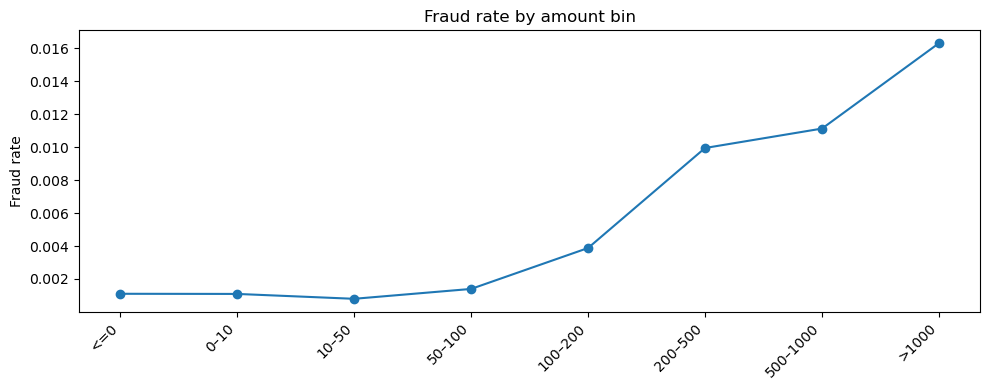

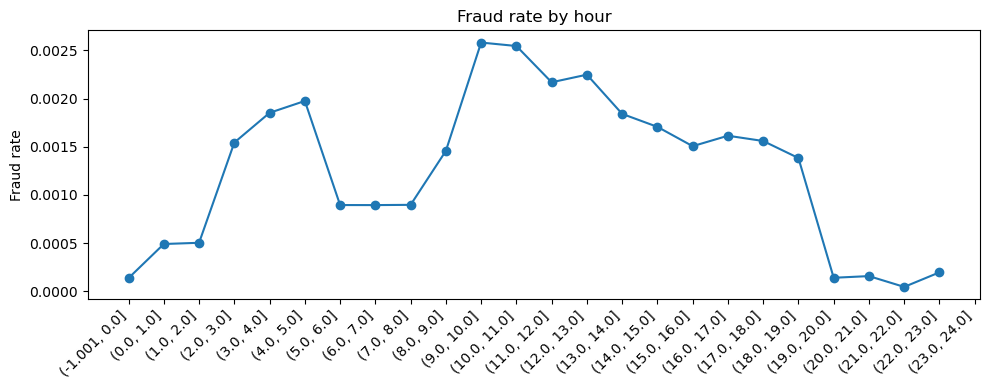

In [31]:
import matplotlib.pyplot as plt

def plot_fraud_rate_table(table, x_col='bin', title='Fraud rate'):
    plt.figure(figsize=(10, 4))
    plt.plot(table[x_col].astype(str), table['fraud_rate'], marker='o')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Fraud rate')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_fraud_rate_table(fraud_amount, title='Fraud rate by amount bin')
plot_fraud_rate_table(fraud_hour, x_col='bin', title='Fraud rate by hour')


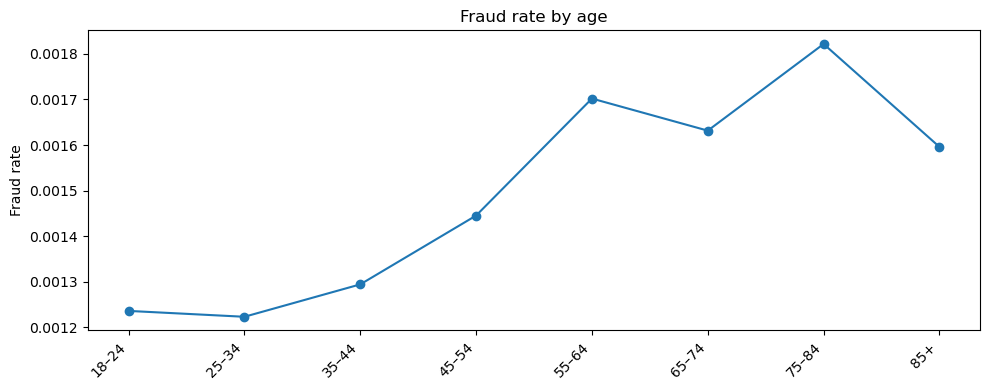

In [47]:
plot_fraud_rate_table(fraud_age, x_col='bin', title='Fraud rate by age')

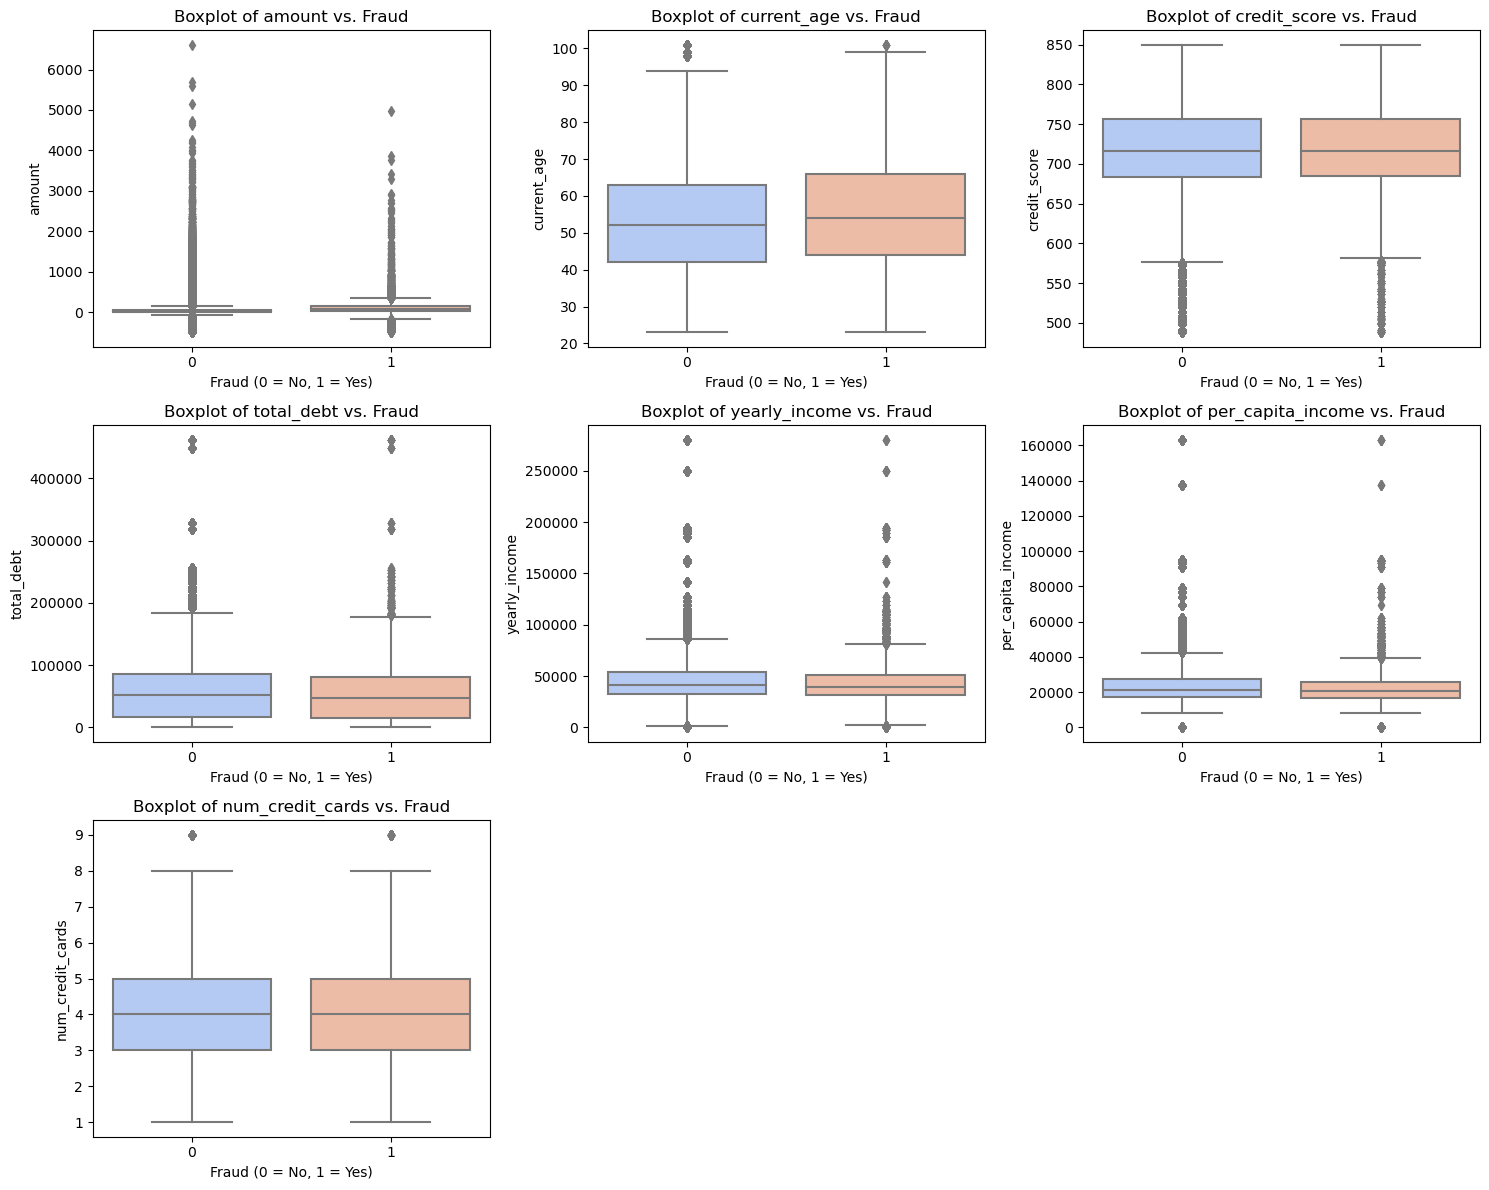

In [36]:

output_dir = r"..\reports\figures\categorical_fraud_plots"
os.makedirs(output_dir, exist_ok=True)
numerical_features = ['amount', 'current_age', 'credit_score', 'total_debt',
                      'yearly_income', 'per_capita_income', 'num_credit_cards']
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df['target'], y=df[feature], palette="coolwarm")
    plt.title(f"Boxplot of {feature} vs. Fraud")
    plt.xlabel("Fraud (0 = No, 1 = Yes)")
    plt.ylabel(feature)

plt.tight_layout()
# Save BEFORE showing
save_path = os.path.join(output_dir, f"{feature}_top{TOP_N}_boxplot.png")
plt.savefig(save_path, dpi=300)
plt.show()

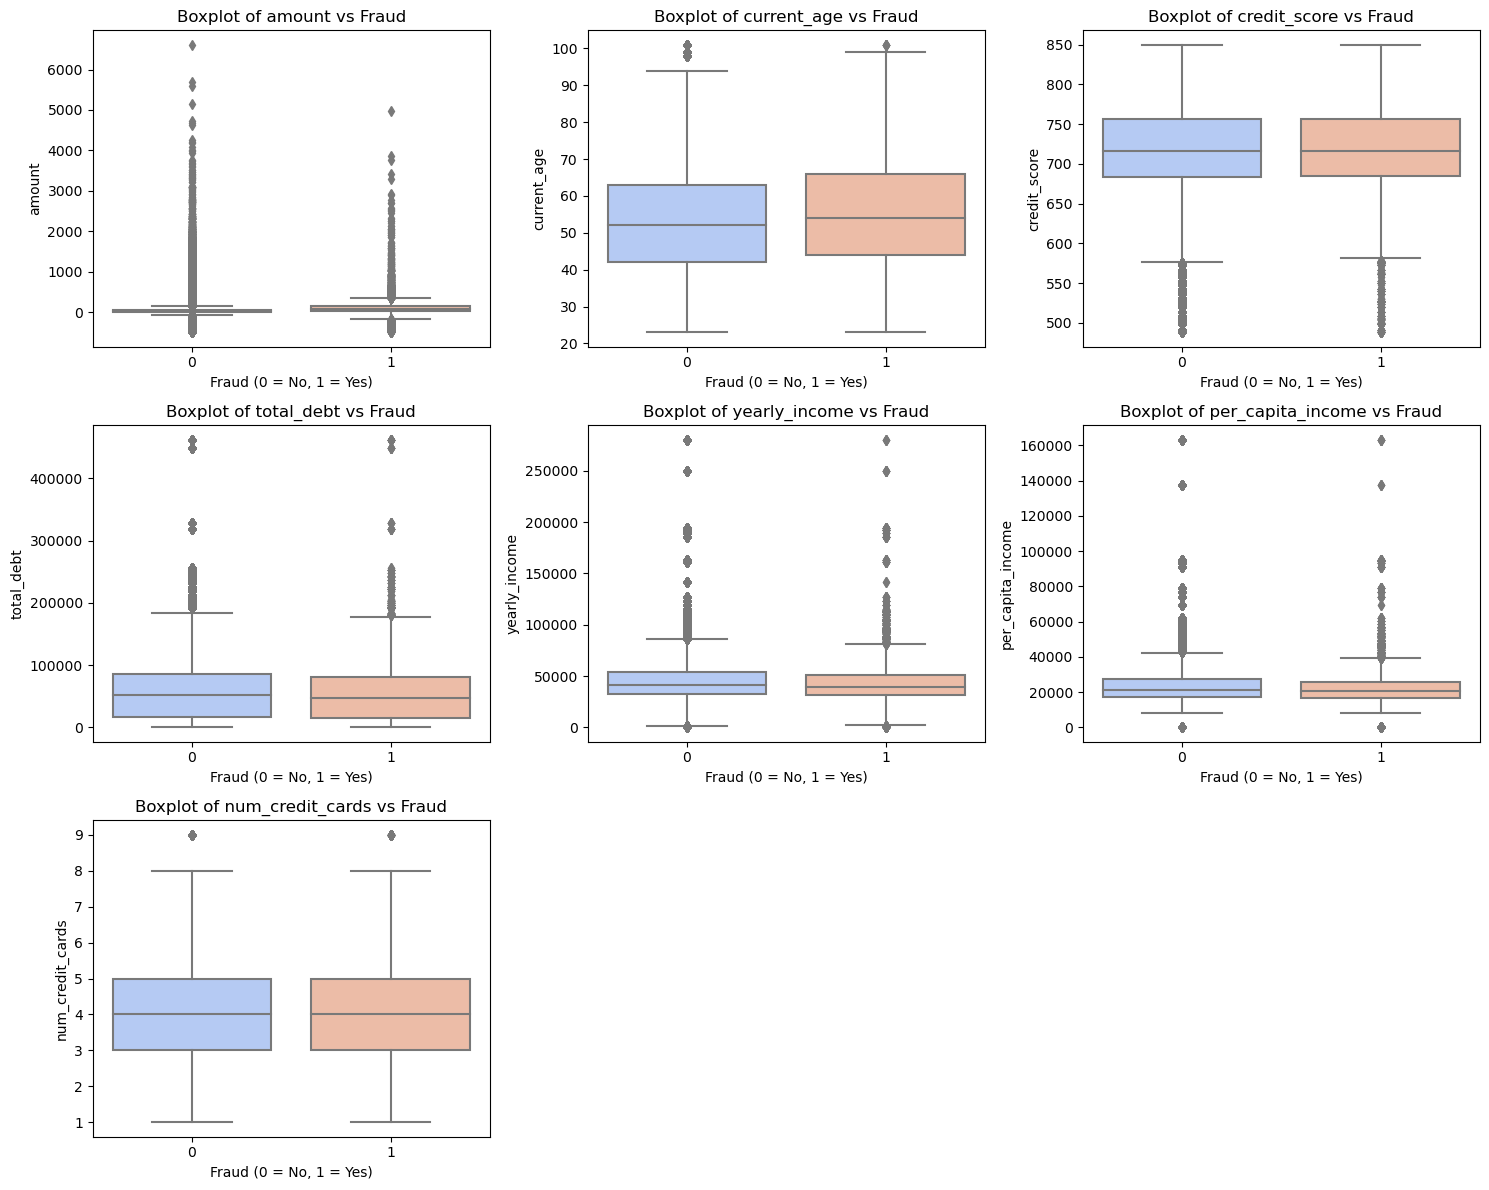

Saved to: ..\reports\figures\numerical_fraud_plots\numerical_features_fraud_boxplots.png


In [37]:
output_dir = r"..\reports\figures\numerical_fraud_plots"
os.makedirs(output_dir, exist_ok=True)

numerical_features = [
    'amount', 'current_age', 'credit_score', 'total_debt',
    'yearly_income', 'per_capita_income', 'num_credit_cards'
]

plt.figure(figsize=(15, 12))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df['target'], y=df[feature], palette="coolwarm")
    plt.title(f"Boxplot of {feature} vs Fraud")
    plt.xlabel("Fraud (0 = No, 1 = Yes)")
    plt.ylabel(feature)

plt.tight_layout()

# Correct filename for the whole grid
save_path = os.path.join(output_dir, "numerical_features_fraud_boxplots.png")
plt.savefig(save_path, dpi=300)

plt.show()

print("Saved to:", save_path)


In [38]:


#  Compute fraud rate per hour
fraud_rate_per_hour = (
    df.groupby('transaction_hour')['target']  # label column is 'target'
      .mean()
      .reset_index()
)

#  Create output folder
output_dir = r"..\reports\figures\numerical_fraud_plots"
os.makedirs(output_dir, exist_ok=True)

#  Plot fraud rate by hour
fig = px.bar(
    fraud_rate_per_hour,
    x='transaction_hour',
    y='target',
    title="Fraud Rate by Hour of Transaction",
    labels={'transaction_hour': 'Transaction Hour', 'target': 'Fraud Rate'},
    text_auto=True,
    color='target',
    color_continuous_scale='Reds'
)

fig.update_layout(
    xaxis_title="Transaction Hour",
    yaxis_title="Fraud Rate",
    template="plotly_dark",
    hovermode="x unified"
)

#  Save BEFORE showing
save_path = os.path.join(output_dir, "fraud_rate_by_hour.png")
fig.write_image(save_path)   # requires 'pip install -U kaleido'

fig.show()

print("Saved to:", save_path)

Saved to: ..\reports\figures\numerical_fraud_plots\fraud_rate_by_hour.png


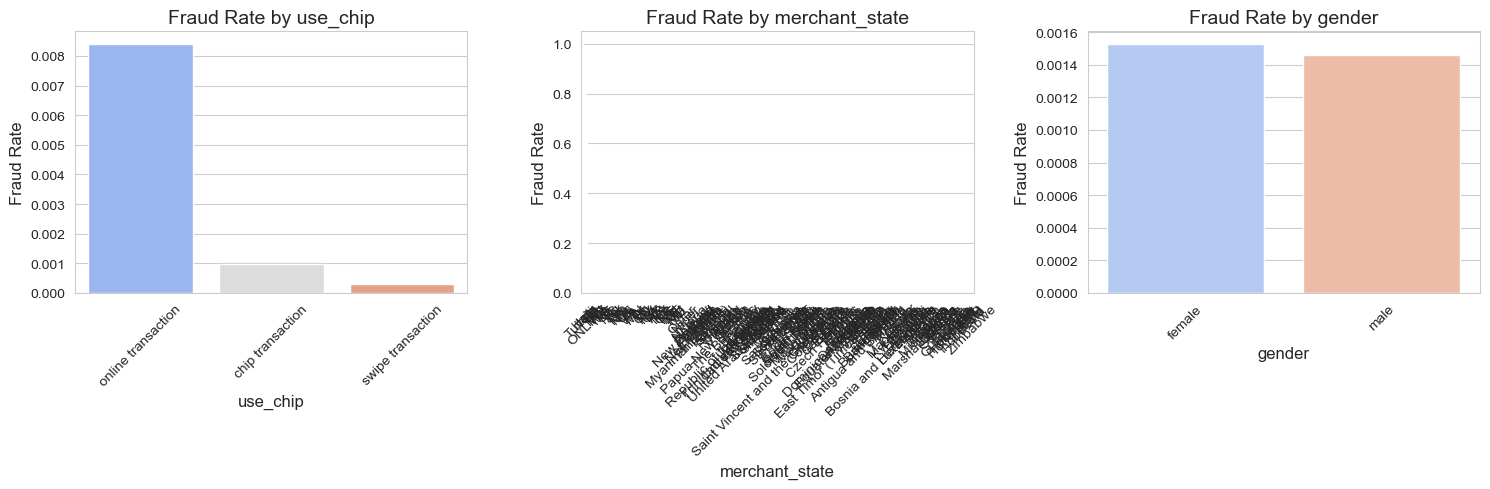

Saved to: ..\reports\figures\categorical_fraud_plots\categorical_features_fraud_barplots.png


In [49]:
output_dir = r"..\reports\figures\categorical_fraud_plots"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(15, 5))
sns.set_style("whitegrid")

# List of categorical variables to analyze
categorical_features = ["use_chip", "merchant_state", "gender"]

# Plot each categorical variable
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(1, 3, i)
    fraud_rates = df.groupby(feature)["target"].mean().sort_values(ascending=False)
    sns.barplot(x=fraud_rates.index, y=fraud_rates.values, palette="coolwarm")

    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Fraud Rate", fontsize=12)
    plt.title(f"Fraud Rate by {feature}", fontsize=14)
    plt.xticks(rotation=45)

# Adjust layout and display plot
plt.tight_layout()
# Correct filename for the whole grid
save_path = os.path.join(output_dir, "categorical_features_fraud_barplots.png")
plt.savefig(save_path, dpi=300)

plt.show()

print("Saved to:", save_path)


#    FRAUD-FOCUSED EDA — CATEGORICAL FEATURES

This section analyzes fraud behavior across categorical variables using:
1. Fraud-rate tables
2. Fraud-rate plots for top categories
3. Insights

In [50]:
def fraud_rate_by_category(df, feature, top_n=20, min_count=500):
    """
    Compute fraud rate for a categorical feature.
    Filters out categories with very low volume to avoid noise.
    Returns top_n categories by volume.
    """
    grp = (
        df.groupby(feature)['target']
        .agg(['count', 'sum', 'mean'])
        .rename(columns={'count': 'n_txn', 'sum': 'n_fraud', 'mean': 'fraud_rate'})
        .sort_values('n_txn', ascending=False)
    )
    grp = grp[grp['n_txn'] >= min_count]
    return grp.head(top_n).reset_index()


In [54]:


# Folder to save plots
output_dir = r"..\reports\figures\fraud_categorical_plots"
os.makedirs(output_dir, exist_ok=True)

def plot_fraud_rate_bar(table, feature_name, category_col, top_k=None, save=True):
    """
    table: fraud-rate table with columns [category_col, n_txn, n_fraud, fraud_rate]
    feature_name: logical name for the feature (e.g. 'use_chip')
    category_col: column name holding the category values (e.g. 'use_chip')
    top_k: optionally limit to top_k rows (by n_txn)
    """
    df_plot = table.copy()
    
    # Sort by fraud_rate descending for visual emphasis
    df_plot = df_plot.sort_values('fraud_rate', ascending=False)
    
    if top_k is not None:
        df_plot = df_plot.head(top_k)
    
    plt.figure(figsize=(10, 4))
    plt.bar(df_plot[category_col].astype(str), df_plot['fraud_rate'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Fraud Rate")
    plt.title(f"Fraud Rate by {feature_name}")
    plt.tight_layout()
    
    if save:
        fname = f"fraud_rate_by_{feature_name}.png"
        save_path = os.path.join(output_dir, fname)
        plt.savefig(save_path, dpi=300)
        print(f"Saved: {save_path}")
    
    plt.show()
    plt.close()


In [51]:
categorical_features = [
    'use_chip', 'card_type', 'card_brand',
    'merchant_category_code', 'mcc_description',
    'merchant_state', 'merchant_city', 'gender'
]

fraud_cat_tables = {}

for col in categorical_features:
    if col in df.columns:
        print(f"===== Fraud Rate for {col} =====")
        table = fraud_rate_by_category(df, col)
        display(table)
        fraud_cat_tables[col] = table


===== Fraud Rate for use_chip =====


,use_chip,n_txn,n_fraud,fraud_rate
0,swipe transaction,4668212,1377,0.000295
1,chip transaction,3202776,3176,0.000992
2,online transaction,1043975,8779,0.008409


===== Fraud Rate for card_type =====


,card_type,n_txn,n_fraud,fraud_rate
0,Debit,5548196,7464,0.001345
1,Credit,2753467,4490,0.001631
2,Debit (Prepaid),613300,1378,0.002247


===== Fraud Rate for card_brand =====


...

,merchant_state,n_txn,n_fraud,fraud_rate
0,ONLINE,1047865,8779,0.008378
1,CA,956356,127,0.000133
2,TX,677139,76,0.000112
3,NY,574521,58,0.000101
4,FL,469600,63,0.000134
5,OH,324098,316,0.000975
6,IL,313592,36,0.000115
7,NC,286937,44,0.000153
8,PA,280037,33,0.000118
9,MI,266745,39,0.000146


===== Fraud Rate for merchant_city =====


,merchant_city,n_txn,n_fraud,fraud_rate
0,ONLINE,1047865,8779,0.008378
1,Houston,98502,1,0.000010
2,Miami,58680,3,0.000051
3,Brooklyn,56173,4,0.000071
4,Los Angeles,54969,4,0.000073
5,Chicago,48652,0,0.000000
6,Dallas,48136,2,0.000042
7,Louisville,44160,1,0.000023
8,Philadelphia,41126,0,0.000000
9,San Antonio,39544,0,0.000000


===== Fraud Rate for gender =====


,gender,n_txn,n_fraud,fraud_rate
0,female,4567172,6982,0.001529
1,male,4347791,6350,0.001461


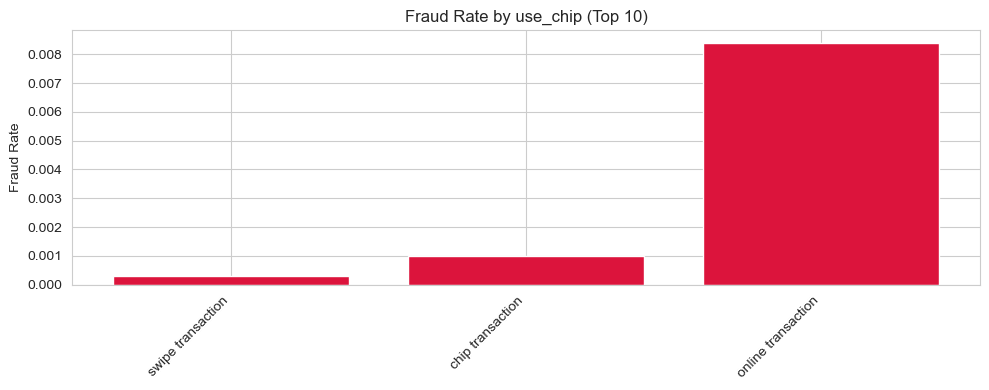

In [52]:
import matplotlib.pyplot as plt

def plot_fraud_rate_cat(result_df, feature, top_k=10):
    tmp = result_df.head(top_k)

    plt.figure(figsize=(10, 4))
    plt.bar(tmp[feature].astype(str), tmp['fraud_rate'], color='crimson')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Fraud Rate')
    plt.title(f'Fraud Rate by {feature} (Top {top_k})')
    plt.tight_layout()
    plt.show()

# Example:
plot_fraud_rate_cat(fraud_cat_tables['use_chip'], 'use_chip')


Saved: ..\reports\figures\fraud_categorical_plots\fraud_rate_by_use_chip.png


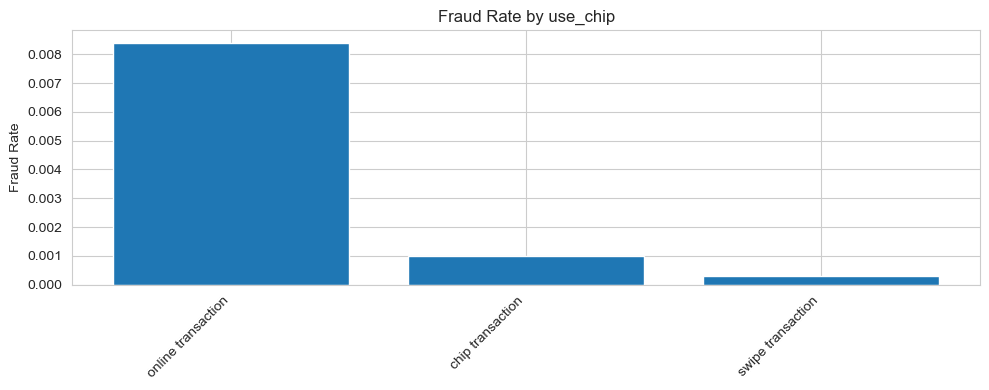

In [55]:
plot_fraud_rate_bar(
    fraud_cat_tables['use_chip'], 
    feature_name='use_chip', 
    category_col='use_chip'
)

Saved: ..\reports\figures\fraud_categorical_plots\fraud_rate_by_card_type.png


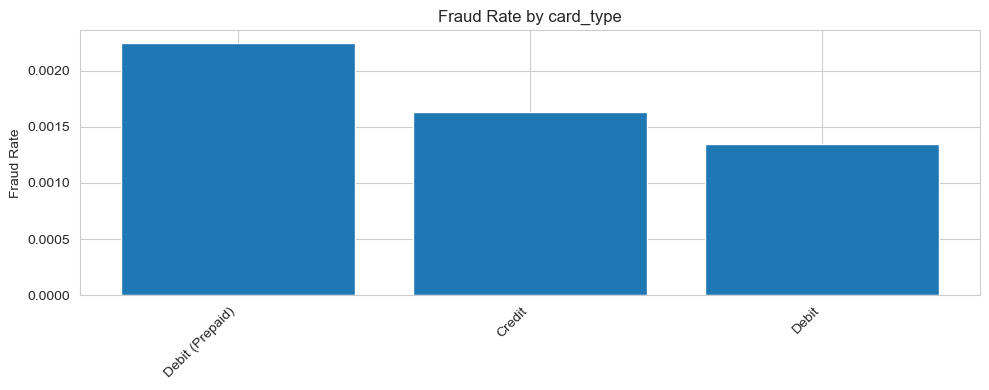

In [56]:
plot_fraud_rate_bar(
    fraud_cat_tables['card_type'], 
    feature_name='card_type', 
    category_col='card_type'
)

Saved: ..\reports\figures\fraud_categorical_plots\fraud_rate_by_card_brand.png


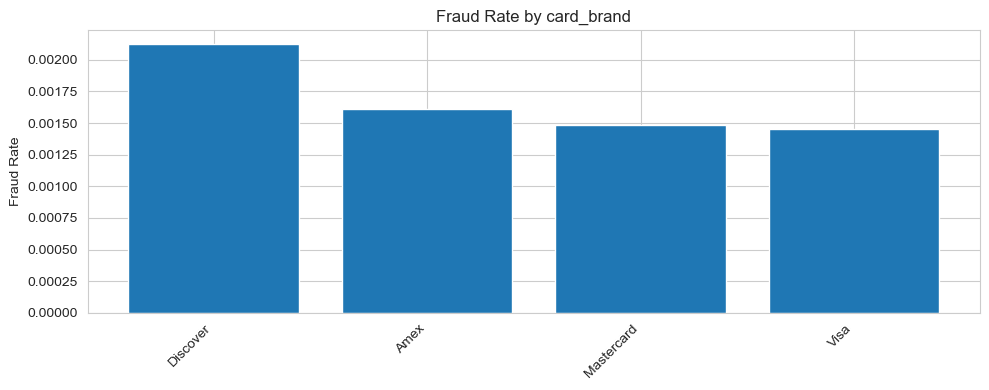

In [57]:
plot_fraud_rate_bar(
    fraud_cat_tables['card_brand'], 
    feature_name='card_brand', 
    category_col='card_brand'
)


Saved: ..\reports\figures\fraud_categorical_plots\fraud_rate_by_merchant_category_code.png


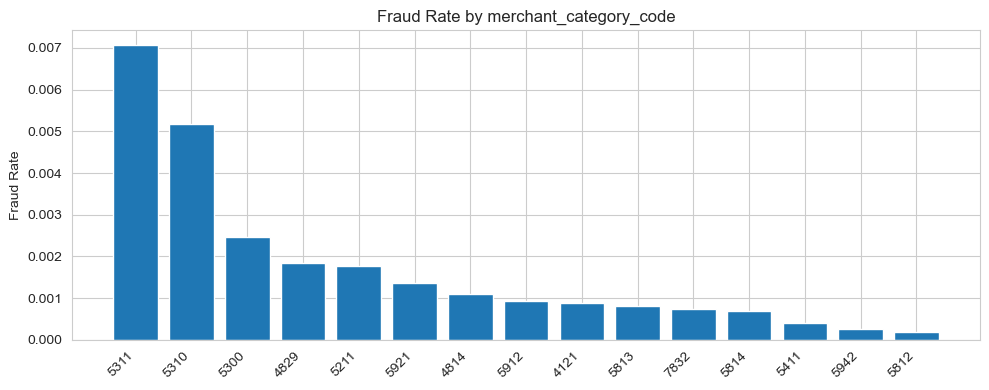

In [58]:
# For MCC and description (limit to top 15 by fraud_rate)
plot_fraud_rate_bar(
    fraud_cat_tables['merchant_category_code'], 
    feature_name='merchant_category_code', 
    category_col='merchant_category_code',
    top_k=15
)

Saved: ..\reports\figures\fraud_categorical_plots\fraud_rate_by_mcc_description.png


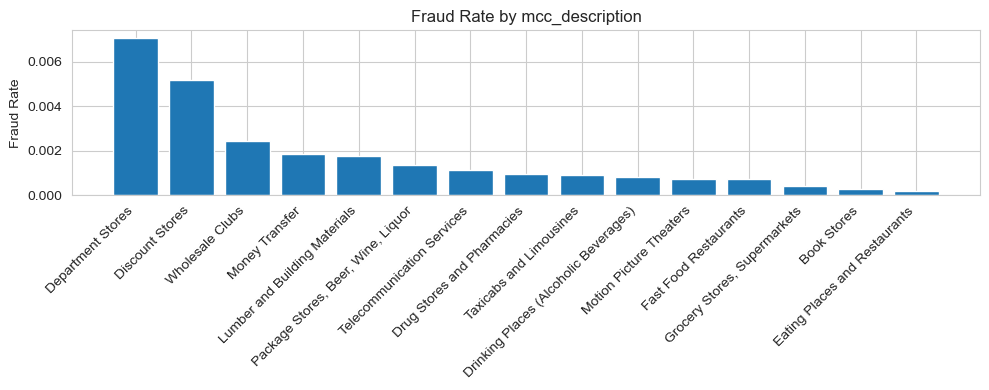

In [59]:
plot_fraud_rate_bar(
    fraud_cat_tables['mcc_description'], 
    feature_name='mcc_description', 
    category_col='mcc_description',
    top_k=15
)

Saved: ..\reports\figures\fraud_categorical_plots\fraud_rate_by_merchant_state.png


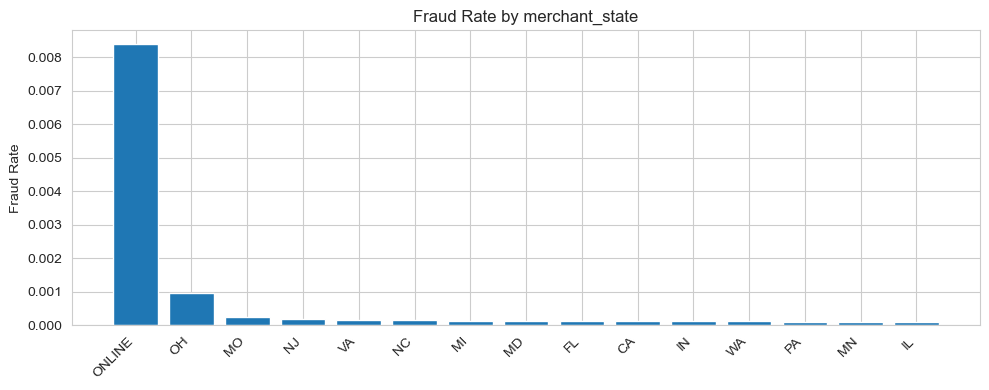

In [60]:
# For state and city, also limit top_k to avoid clutter
plot_fraud_rate_bar(
    fraud_cat_tables['merchant_state'], 
    feature_name='merchant_state', 
    category_col='merchant_state',
    top_k=15
)

Saved: ..\reports\figures\fraud_categorical_plots\fraud_rate_by_merchant_city.png


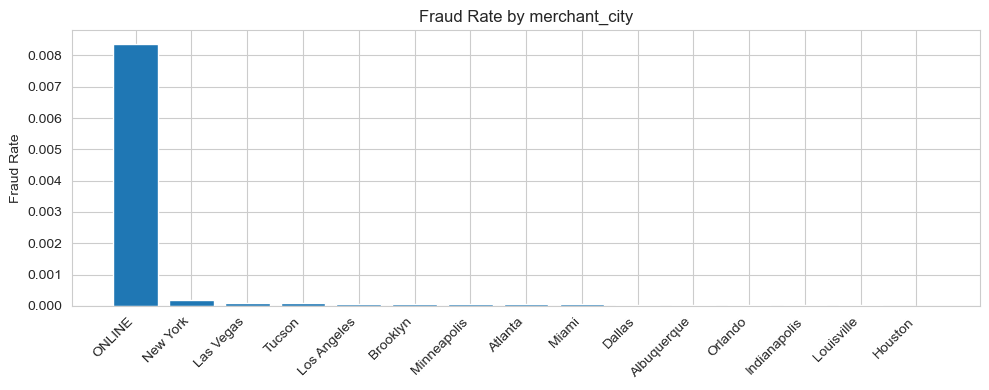

In [61]:
plot_fraud_rate_bar(
    fraud_cat_tables['merchant_city'], 
    feature_name='merchant_city', 
    category_col='merchant_city',
    top_k=15
)

Saved: ..\reports\figures\fraud_categorical_plots\fraud_rate_by_gender.png


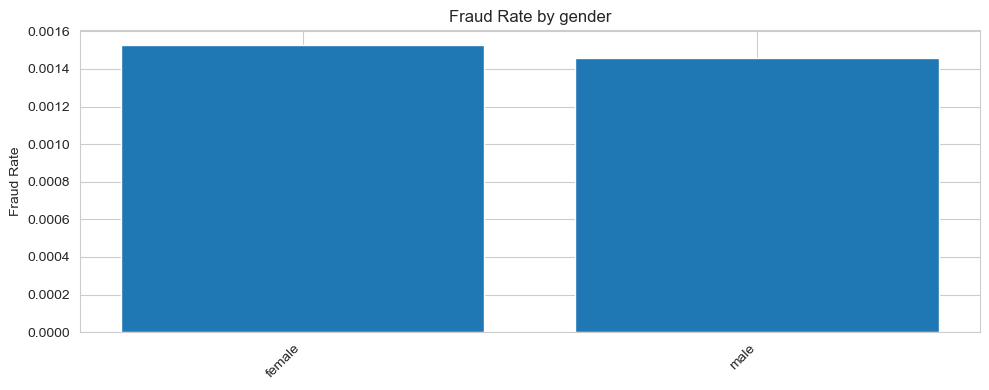

In [62]:
plot_fraud_rate_bar(
    fraud_cat_tables['gender'], 
    feature_name='gender', 
    category_col='gender'
)


In [63]:


# Amount bins (same idea as before)
amount_bins = [-np.inf, 0, 10, 50, 100, 200, 500, 1000, np.inf]
amount_labels = ["<=0", "0–10", "10–50", "50–100", "100–200", "200–500", "500–1000", ">1000"]
df['amount_bin'] = pd.cut(df['amount'], bins=amount_bins, labels=amount_labels, include_lowest=True)

# Hour bins
hour_bins = [-1, 6, 12, 18, 24]   # night, morning, afternoon, evening
hour_labels = ["Night(0–6)", "Morning(6–12)", "Afternoon(12–18)", "Evening(18–24)"]
df['hour_bin'] = pd.cut(df['transaction_hour'], bins=hour_bins, labels=hour_labels, include_lowest=True)

# Income bins
income_bins = [0, 20000, 40000, 60000, 80000, 120000, np.inf]
income_labels = ["<=20k", "20–40k", "40–60k", "60–80k", "80–120k", ">120k"]
df['income_bin'] = pd.cut(df['yearly_income'], bins=income_bins, labels=income_labels, include_lowest=True)


In [64]:
def fraud_rate_2d(df, row_feature, col_feature):
    """
    Returns a pivot table with fraud_rate as values, indexed by row_feature x col_feature.
    """
    tmp = (
        df.groupby([row_feature, col_feature])['target']
          .mean()
          .reset_index()
          .rename(columns={'target': 'fraud_rate'})
    )
    pivot = tmp.pivot(index=row_feature, columns=col_feature, values='fraud_rate')
    return pivot


In [65]:

output_dir = r"..\reports\figures\interaction_fraud_plots"
os.makedirs(output_dir, exist_ok=True)

def plot_fraud_heatmap(pivot, row_feature, col_feature, fmt=".4f"):
    plt.figure(figsize=(8, 5))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=fmt,
        cmap="Reds",
        cbar_kws={'label': 'Fraud Rate'}
    )
    plt.title(f"Fraud Rate: {row_feature} × {col_feature}")
    plt.xlabel(col_feature)
    plt.ylabel(row_feature)
    plt.tight_layout()
    
    save_path = os.path.join(output_dir, f"fraud_heatmap_{row_feature}_x_{col_feature}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()
    
    print("Saved:", save_path)


Channel × Amount

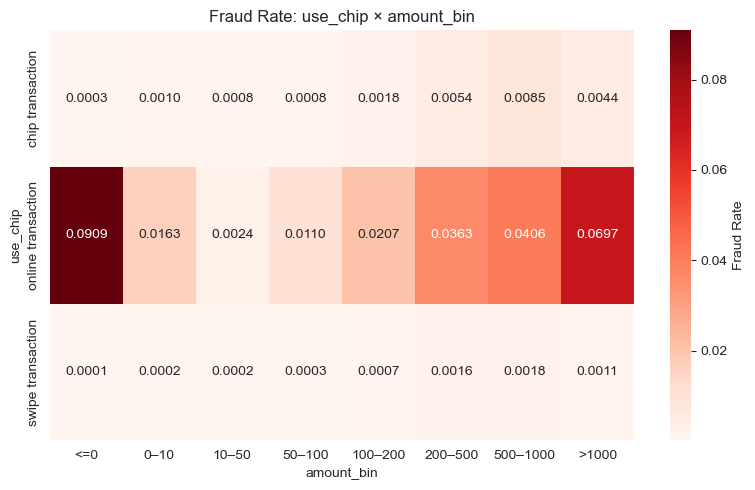

Saved: ..\reports\figures\interaction_fraud_plots\fraud_heatmap_use_chip_x_amount_bin.png


In [66]:
# Ensure use_chip is the cleaned channel feature
pivot_channel_amount = fraud_rate_2d(df, 'use_chip', 'amount_bin')
plot_fraud_heatmap(pivot_channel_amount, 'use_chip', 'amount_bin')


Channel × Hour

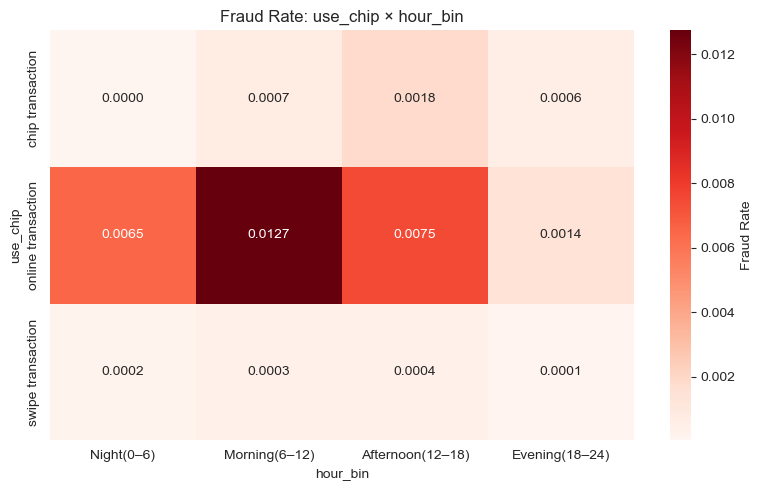

Saved: ..\reports\figures\interaction_fraud_plots\fraud_heatmap_use_chip_x_hour_bin.png


In [67]:
pivot_channel_hour = fraud_rate_2d(df, 'use_chip', 'hour_bin')
plot_fraud_heatmap(pivot_channel_hour, 'use_chip', 'hour_bin')


Card Type × Channel

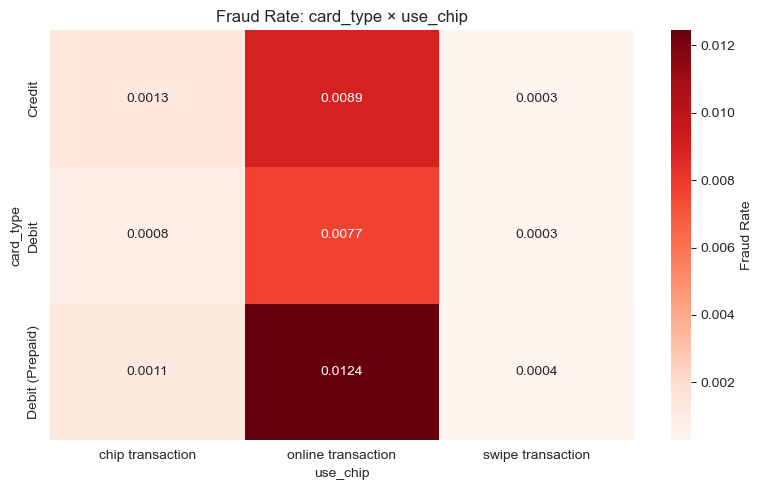

Saved: ..\reports\figures\interaction_fraud_plots\fraud_heatmap_card_type_x_use_chip.png


In [68]:
pivot_cardtype_channel = fraud_rate_2d(df, 'card_type', 'use_chip')
plot_fraud_heatmap(pivot_cardtype_channel, 'card_type', 'use_chip')


MCC × Channel (top MCCs only to avoid noise)

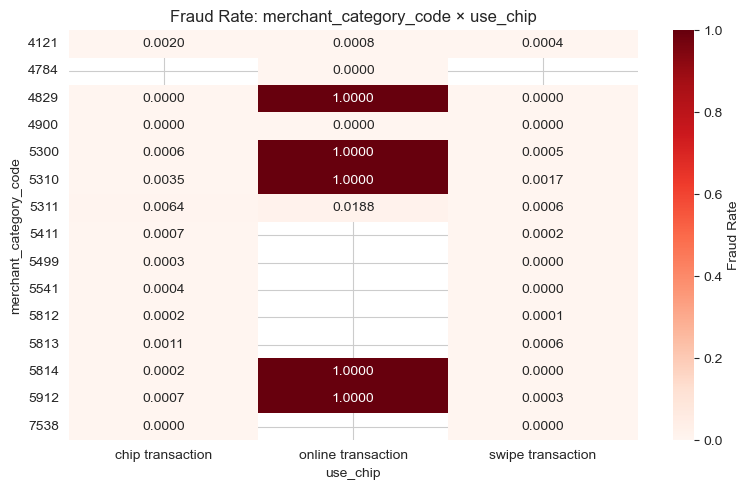

Saved: ..\reports\figures\interaction_fraud_plots\fraud_heatmap_merchant_category_code_x_use_chip.png


In [69]:
# Get top MCCs by volume
top_mcc = (
    df['merchant_category_code']
      .value_counts()
      .head(15)
      .index
)

df_top_mcc = df[df['merchant_category_code'].isin(top_mcc)]

pivot_mcc_channel = fraud_rate_2d(df_top_mcc, 'merchant_category_code', 'use_chip')
plot_fraud_heatmap(pivot_mcc_channel, 'merchant_category_code', 'use_chip')


Amount × Income

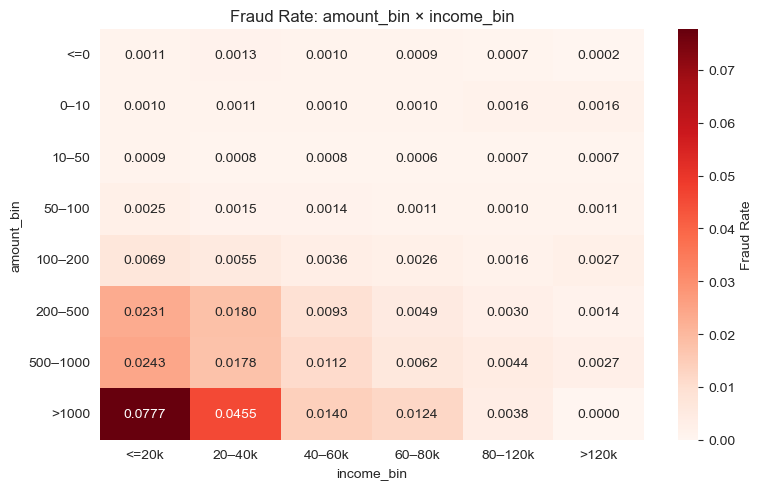

Saved: ..\reports\figures\interaction_fraud_plots\fraud_heatmap_amount_bin_x_income_bin.png


In [70]:
pivot_amount_income = fraud_rate_2d(df, 'amount_bin', 'income_bin')
plot_fraud_heatmap(pivot_amount_income, 'amount_bin', 'income_bin')
